In [1]:
import pandas as pd
import numpy as np

ml_data = pd.read_csv(
    "../data/processed/karhut_ml_dataset.csv"
)

ml_data["date"] = pd.to_datetime(ml_data["date"])

print("Shape:", ml_data.shape)
print("Date:", ml_data["date"].min(), "→", ml_data["date"].max())
print("Cells:", ml_data["cell_id"].nunique())

Shape: (34272, 39)
Date: 2026-05-08 00:00:00 → 2026-09-10 00:00:00
Cells: 272


In [2]:
feature_cols = [
    # Fire history
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7",

    # Weather
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean",

    # Air Quality
    "pm2_5_mean",
    "pm2_5_max",
    "aerosol_optical_depth_mean",
    "carbon_monoxide_mean",
    "formaldehyde_mean"
]

target_col = "target_fire_active_t1"

X = ml_data[feature_cols]
y = ml_data[target_col].astype(int)

print("X:", X.shape)
print("y:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportion:")
print(y.value_counts(normalize=True))

X: (34272, 25)
y: (34272,)

Target distribution:
target_fire_active_t1
0    27990
1     6282
Name: count, dtype: int64

Target proportion:
target_fire_active_t1
0    0.816702
1    0.183298
Name: proportion, dtype: float64


In [3]:
train_data = ml_data[
    ml_data["date"] < "2026-08-01"
].copy()

val_data = ml_data[
    (ml_data["date"] >= "2026-08-01") &
    (ml_data["date"] < "2026-09-01")
].copy()

test_data = ml_data[
    ml_data["date"] >= "2026-09-01"
].copy()

print("TRAIN:", train_data.shape)
print("VAL  :", val_data.shape)
print("TEST :", test_data.shape)

TRAIN: (23120, 39)
VAL  : (8432, 39)
TEST : (2720, 39)


In [4]:
X_train = train_data[feature_cols]
y_train = train_data[target_col].astype(int)

X_val = val_data[feature_cols]
y_val = val_data[target_col].astype(int)

X_test = test_data[feature_cols]
y_test = test_data[target_col].astype(int)

In [5]:
print("\nTrain positive rate:",
      y_train.mean())

print("Validation positive rate:",
      y_val.mean())

print("Test positive rate:",
      y_test.mean())


Train positive rate: 0.11042387543252595
Validation positive rate: 0.3391840607210626
Test positive rate: 0.31948529411764703


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['fire_count_lag1','fire_count_lag3','fire_count_lag7',..., 'aerosol_optical_depth_mean','carbon_monoxide_mean','formaldehyde_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [7]:
y_val_proba_lr = logreg_model.predict_proba(X_val)[:, 1]

In [8]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

def evaluate_model(y_true, y_proba, threshold=0.5):

    y_pred = (
        y_proba >= threshold
    ).astype(int)

    return {
        "PR-AUC": average_precision_score(
            y_true,
            y_proba
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Confusion Matrix": confusion_matrix(
            y_true,
            y_pred
        )
    }

In [9]:
lr_val_result = evaluate_model(
    y_val,
    y_val_proba_lr,
    threshold=0.5
)

lr_val_result

{'PR-AUC': 0.8926803842671943,
 'Precision': 0.7433706540954625,
 'Recall': 0.8821678321678321,
 'F1': 0.8068436200831468,
 'Accuracy': 0.8567362428842504,
 'Confusion Matrix': array([[4701,  871],
        [ 337, 2523]])}

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_val_proba_rf = rf_model.predict_proba(
    X_val
)[:, 1]

rf_val_result = evaluate_model(
    y_val,
    y_val_proba_rf,
    threshold=0.5
)

rf_val_result

{'PR-AUC': 0.8447969107343257,
 'Precision': 0.859542697153523,
 'Recall': 0.644055944055944,
 'F1': 0.7363581850889467,
 'Accuracy': 0.8435721062618596,
 'Confusion Matrix': array([[5271,  301],
        [1018, 1842]])}

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

y_val_proba_gb = gb_model.predict_proba(
    X_val
)[:, 1]

gb_val_result = evaluate_model(
    y_val,
    y_val_proba_gb,
    threshold=0.5
)

gb_val_result

{'PR-AUC': 0.8853661099487664,
 'Precision': 0.7269850402761795,
 'Recall': 0.8835664335664336,
 'F1': 0.7976641414141414,
 'Accuracy': 0.8479601518026565,
 'Confusion Matrix': array([[4623,  949],
        [ 333, 2527]])}

In [1]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [2]:
import pandas as pd
import numpy as np

In [5]:
ml_data = pd.read_csv("../data/processed/karhut_ml_dataset.csv")

print("Shape:", ml_data.shape)
ml_data.head()

Shape: (34272, 39)


,cell_id,date,n_detections,frp_sum,frp_mean,frp_max,fire_active,target_fire_active_t1,fire_count_lag1,fire_count_lag3,...,wind_speed_mean,wind_speed_max,wind_u_mean,wind_v_mean,wind_direction_mean,pm2_5_mean,pm2_5_max,aerosol_optical_depth_mean,carbon_monoxide_mean,formaldehyde_mean
0,-0.75_108.0,2026-05-08,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,...,6.679167,15.0,-3.475577,3.189461,132.541922,4.233333,6.3,0.210417,109.416667,0.900000
1,-0.75_108.0,2026-05-09,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,...,9.020833,14.5,5.493204,5.629225,224.299336,3.375000,4.1,0.096250,106.125000,0.825000
2,-0.75_108.0,2026-05-10,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,...,3.325000,7.1,-0.728517,-0.354466,64.054355,3.191667,5.1,0.072500,106.375000,1.220833
3,-0.75_108.0,2026-05-11,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,...,7.683333,14.7,-0.473697,-4.136161,6.533375,4.045833,6.4,0.142083,107.916667,0.870833
4,-0.75_108.0,2026-05-12,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,...,11.966667,20.5,-10.974184,1.647696,98.538776,7.725000,9.1,0.240417,117.833333,1.120833


In [6]:
import pandas as pd
import numpy as np

ml_data = pd.read_csv("../data/processed/karhut_ml_dataset.csv")

ml_data["date"] = pd.to_datetime(ml_data["date"])

print("Shape:", ml_data.shape)
print("Date:", ml_data["date"].min(), "sampai", ml_data["date"].max())
print("Unique cells:", ml_data["cell_id"].nunique())

Shape: (34272, 39)
Date: 2026-05-08 00:00:00 sampai 2026-09-10 00:00:00
Unique cells: 272


In [7]:
feature_cols = [
    # Fire history
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7",

    # Weather
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean",

    # Air Quality
    "pm2_5_mean",
    "pm2_5_max",
    "aerosol_optical_depth_mean",
    "carbon_monoxide_mean",
    "formaldehyde_mean"
]

target_col = "target_fire_active_t1"

print("Jumlah fitur:", len(feature_cols))
print(feature_cols)

Jumlah fitur: 25
['fire_count_lag1', 'fire_count_lag3', 'fire_count_lag7', 'frp_sum_lag1', 'frp_sum_lag3', 'frp_sum_lag7', 'fire_count_roll3', 'fire_count_roll7', 'frp_sum_roll3', 'frp_sum_roll7', 'temperature_mean', 'temperature_max', 'relative_humidity_mean', 'precipitation_sum', 'boundary_layer_height_mean', 'vapour_pressure_deficit_mean', 'wind_speed_mean', 'wind_speed_max', 'wind_u_mean', 'wind_v_mean', 'pm2_5_mean', 'pm2_5_max', 'aerosol_optical_depth_mean', 'carbon_monoxide_mean', 'formaldehyde_mean']


In [8]:
X = ml_data[feature_cols]
y = ml_data[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nDistribusi target:")
print(y.value_counts())

print("\nProporsi target:")
print(y.value_counts(normalize=True))

X shape: (34272, 25)
y shape: (34272,)

Distribusi target:
target_fire_active_t1
0.0    27990
1.0     6282
Name: count, dtype: int64

Proporsi target:
target_fire_active_t1
0.0    0.816702
1.0    0.183298
Name: proportion, dtype: float64


In [9]:
train_mask = ml_data["date"] < "2026-08-01"

val_mask = (
    (ml_data["date"] >= "2026-08-01") &
    (ml_data["date"] < "2026-09-01")
)

test_mask = ml_data["date"] >= "2026-09-01"

X_train = ml_data.loc[train_mask, feature_cols]
y_train = ml_data.loc[train_mask, target_col]

X_val = ml_data.loc[val_mask, feature_cols]
y_val = ml_data.loc[val_mask, target_col]

X_test = ml_data.loc[test_mask, feature_cols]
y_test = ml_data.loc[test_mask, target_col]

print("TRAIN :", X_train.shape)
print("VAL   :", X_val.shape)
print("TEST  :", X_test.shape)

TRAIN : (23120, 25)
VAL   : (8432, 25)
TEST  : (2720, 25)


In [10]:
split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Start": [
        ml_data.loc[train_mask, "date"].min(),
        ml_data.loc[val_mask, "date"].min(),
        ml_data.loc[test_mask, "date"].min()
    ],
    "End": [
        ml_data.loc[train_mask, "date"].max(),
        ml_data.loc[val_mask, "date"].max(),
        ml_data.loc[test_mask, "date"].max()
    ],
    "Rows": [
        len(y_train),
        len(y_val),
        len(y_test)
    ],
    "Positive": [
        y_train.sum(),
        y_val.sum(),
        y_test.sum()
    ],
    "Positive_Rate": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

split_summary

,Dataset,Start,End,Rows,Positive,Positive_Rate
0,Train,2026-05-08,2026-07-31,23120,2553.0,0.110424
1,Validation,2026-08-01,2026-08-31,8432,2860.0,0.339184
2,Test,2026-09-01,2026-09-10,2720,869.0,0.319485


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)

print("Logistic Regression selesai.")

Logistic Regression selesai.


In [12]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

def evaluate_model(model, X_data, y_data, threshold=0.5):
    y_prob = model.predict_proba(X_data)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        "PR-AUC": average_precision_score(y_data, y_prob),
        "Precision": precision_score(y_data, y_pred, zero_division=0),
        "Recall": recall_score(y_data, y_pred, zero_division=0),
        "F1": f1_score(y_data, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_data, y_pred),
        "Confusion Matrix": confusion_matrix(y_data, y_pred)
    }

    return results

In [13]:
lr_val_result = evaluate_model(
    lr_model,
    X_val,
    y_val
)

lr_val_result

{'PR-AUC': 0.8926803842671943,
 'Precision': 0.7433706540954625,
 'Recall': 0.8821678321678321,
 'F1': 0.8068436200831468,
 'Accuracy': 0.8567362428842504,
 'Confusion Matrix': array([[4701,  871],
        [ 337, 2523]])}

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest selesai.")

Random Forest selesai.


In [15]:
rf_val_result = evaluate_model(
    rf_model,
    X_val,
    y_val
)

rf_val_result

{'PR-AUC': 0.8447969107343257,
 'Precision': 0.859542697153523,
 'Recall': 0.644055944055944,
 'F1': 0.7363581850889467,
 'Accuracy': 0.8435721062618596,
 'Confusion Matrix': array([[5271,  301],
        [1018, 1842]])}

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

gb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Gradient Boosting selesai.")

Gradient Boosting selesai.


In [17]:
gb_val_result = evaluate_model(
    gb_model,
    X_val,
    y_val
)

gb_val_result

{'PR-AUC': 0.8853661099487664,
 'Precision': 0.7269850402761795,
 'Recall': 0.8835664335664336,
 'F1': 0.7976641414141414,
 'Accuracy': 0.8479601518026565,
 'Confusion Matrix': array([[4623,  949],
        [ 333, 2527]])}

In [18]:
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative: 20567
Positive: 2553
scale_pos_weight: 8.056012534273403


In [19]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost selesai.")

XGBoost selesai.


In [20]:
xgb_val_result = evaluate_model(
    xgb_model,
    X_val,
    y_val
)

xgb_val_result

{'PR-AUC': 0.8750043061818886,
 'Precision': 0.762054837693035,
 'Recall': 0.8454545454545455,
 'F1': 0.8015912481352561,
 'Accuracy': 0.8580407969639469,
 'Confusion Matrix': array([[4817,  755],
        [ 442, 2418]])}

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_val_prob = lr_model.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.30, 0.81, 0.01):
    y_val_pred = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, y_val_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_val_pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, y_val_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
43,0.73,0.823050,0.811538,0.817254
45,0.75,0.828654,0.804895,0.816602
42,0.72,0.818405,0.814685,0.816541
46,0.76,0.831640,0.801399,0.816239
47,0.77,0.834674,0.797902,0.815874
41,0.71,0.814286,0.817133,0.815707
37,0.67,0.800606,0.831119,0.815577
38,0.68,0.803735,0.827622,0.815504
44,0.74,0.823991,0.806993,0.815404
40,0.70,0.810858,0.819930,0.815369


In [22]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

FINAL_THRESHOLD = 0.73

y_test_prob = lr_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= FINAL_THRESHOLD).astype(int)

test_pr_auc = average_precision_score(y_test, y_test_prob)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

print("=== FINAL TEST RESULT ===")
print(f"Threshold : {FINAL_THRESHOLD}")
print(f"PR-AUC    : {test_pr_auc:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1        : {test_f1:.4f}")
print(f"Accuracy  : {test_accuracy:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

=== FINAL TEST RESULT ===
Threshold : 0.73
PR-AUC    : 0.8838
Precision : 0.8315
Recall    : 0.7837
F1        : 0.8069
Accuracy  : 0.8801

Confusion Matrix:
[[1713  138]
 [ 188  681]]


In [24]:
# Ambil model Logistic Regression dari pipeline
lr_coefficients = lr_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lr_coefficients
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient,Abs_Coefficient
15,vapour_pressure_deficit_mean,-3.287054,3.287054
12,relative_humidity_mean,-2.818241,2.818241
7,fire_count_roll7,2.418182,2.418182
9,frp_sum_roll7,-1.009071,1.009071
0,fire_count_lag1,0.724527,0.724527
24,formaldehyde_mean,0.543987,0.543987
6,fire_count_roll3,0.475308,0.475308
11,temperature_max,0.471849,0.471849
13,precipitation_sum,-0.446702,0.446702
8,frp_sum_roll3,-0.409877,0.409877


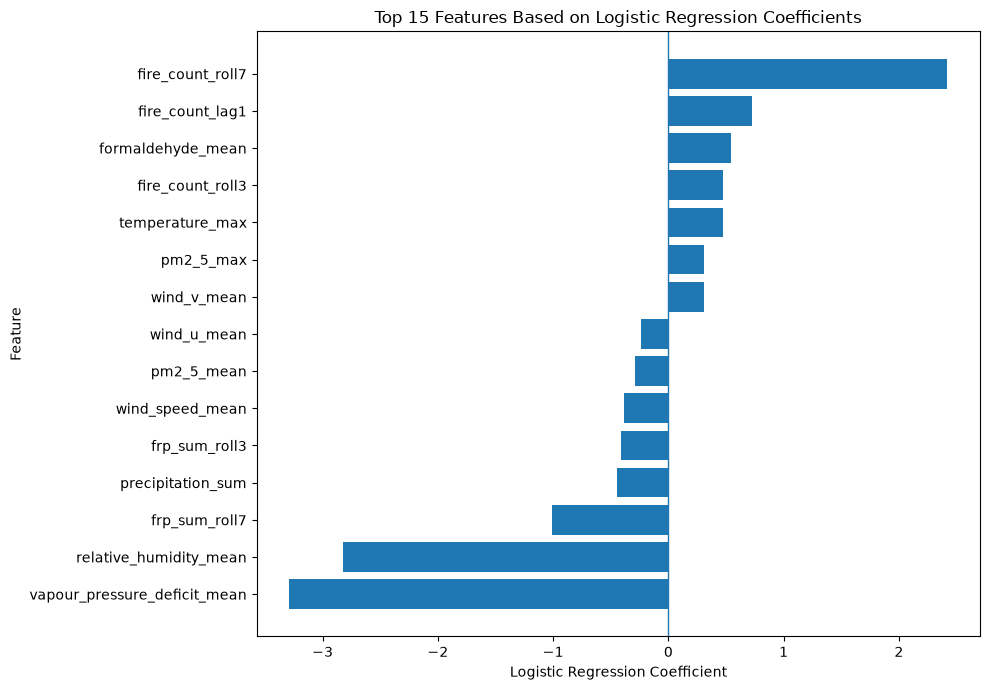

In [25]:
import matplotlib.pyplot as plt

top_n = 15

plot_df = coef_df.head(top_n).sort_values("Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Based on Logistic Regression Coefficients")

plt.tight_layout()
plt.show()

In [26]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    lr_model,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

perm_df = perm_df.sort_values(
    "Importance_Mean",
    ascending=False
)

perm_df.head(15)

,Feature,Importance_Mean,Importance_Std
7,fire_count_roll7,0.507510,0.006215
0,fire_count_lag1,0.151226,0.004632
6,fire_count_roll3,0.113815,0.004375
15,vapour_pressure_deficit_mean,0.080017,0.001031
21,pm2_5_max,0.057863,0.001568
24,formaldehyde_mean,0.055960,0.001345
12,relative_humidity_mean,0.054253,0.001435
9,frp_sum_roll7,0.035167,0.002287
2,fire_count_lag7,0.027882,0.001449
8,frp_sum_roll3,0.018094,0.002270


In [27]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    lr_model,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

perm_df = perm_df.sort_values(
    "Importance_Mean",
    ascending=False
)

perm_df.head(15)

,Feature,Importance_Mean,Importance_Std
7,fire_count_roll7,0.507510,0.006215
0,fire_count_lag1,0.151226,0.004632
6,fire_count_roll3,0.113815,0.004375
15,vapour_pressure_deficit_mean,0.080017,0.001031
21,pm2_5_max,0.057863,0.001568
24,formaldehyde_mean,0.055960,0.001345
12,relative_humidity_mean,0.054253,0.001435
9,frp_sum_roll7,0.035167,0.002287
2,fire_count_lag7,0.027882,0.001449
8,frp_sum_roll3,0.018094,0.002270


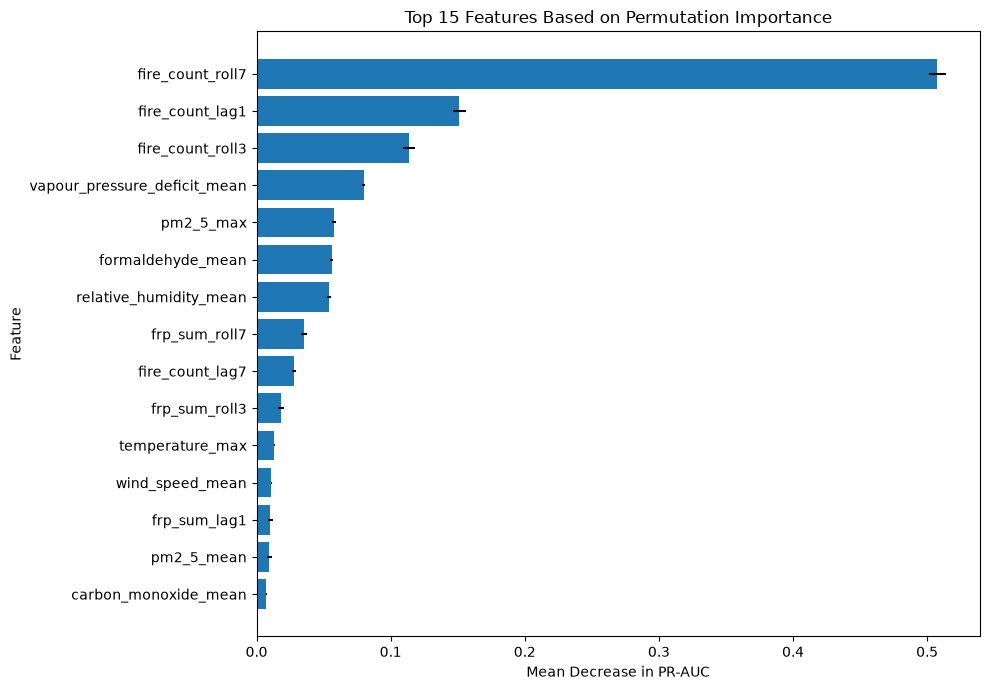

In [28]:
import matplotlib.pyplot as plt

plot_perm = (
    perm_df
    .head(15)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_perm["Feature"],
    plot_perm["Importance_Mean"],
    xerr=plot_perm["Importance_Std"]
)

plt.xlabel("Mean Decrease in PR-AUC")
plt.ylabel("Feature")
plt.title("Top 15 Features Based on Permutation Importance")

plt.tight_layout()
plt.show()

In [29]:
tune_train_mask = (
    (ml_data["date"] >= "2026-05-08") &
    (ml_data["date"] < "2026-07-01")
)

tune_val_mask = (
    (ml_data["date"] >= "2026-07-01") &
    (ml_data["date"] < "2026-08-01")
)

X_tune_train = ml_data.loc[tune_train_mask, feature_cols]
y_tune_train = ml_data.loc[tune_train_mask, target_col]

X_tune_val = ml_data.loc[tune_val_mask, feature_cols]
y_tune_val = ml_data.loc[tune_val_mask, target_col]

print("Tuning train:", X_tune_train.shape)
print("Tuning validation:", X_tune_val.shape)

Tuning train: (14688, 25)
Tuning validation: (8432, 25)


In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

neg = (y_tune_train == 0).sum()
pos = (y_tune_train == 1).sum()

scale_pos_weight = neg / pos

xgb_configs = [
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05
    },
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05
    },
    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05
    },
    {
        "n_estimators": 400,
        "max_depth": 3,
        "learning_rate": 0.03
    },
    {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.03
    }
]

xgb_tuning_results = []

for i, config in enumerate(xgb_configs, start=1):

    model = XGBClassifier(
        **config,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tune_train, y_tune_train)

    y_prob = model.predict_proba(X_tune_val)[:, 1]

    pr_auc = average_precision_score(
        y_tune_val,
        y_prob
    )

    xgb_tuning_results.append({
        "Config": i,
        **config,
        "PR-AUC": pr_auc
    })

xgb_tuning_df = pd.DataFrame(xgb_tuning_results)

xgb_tuning_df.sort_values(
    "PR-AUC",
    ascending=False
)

,Config,n_estimators,max_depth,learning_rate,PR-AUC
3,4,400,3,0.03,0.520539
0,1,200,3,0.05,0.508420
1,2,300,3,0.05,0.499020
4,5,400,4,0.03,0.491117
2,3,300,4,0.05,0.467951


In [31]:
best_xgb_config = (
    xgb_tuning_df
    .sort_values("PR-AUC", ascending=False)
    .iloc[0]
)

best_xgb_config

Config             4.000000
n_estimators     400.000000
max_depth          3.000000
learning_rate      0.030000
PR-AUC             0.520539
Name: 3, dtype: float64

In [32]:
best_xgb = XGBClassifier(
    n_estimators=int(best_xgb_config["n_estimators"]),
    max_depth=int(best_xgb_config["max_depth"]),
    learning_rate=float(best_xgb_config["learning_rate"]),
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

print("Best XGBoost berhasil dilatih.")

Best XGBoost berhasil dilatih.


In [33]:
tuned_xgb_val_result = evaluate_model(
    best_xgb,
    X_val,
    y_val
)

tuned_xgb_val_result

{'PR-AUC': 0.8898118474053706,
 'Precision': 0.7230287503558213,
 'Recall': 0.8881118881118881,
 'F1': 0.7971128197081437,
 'Accuracy': 0.8466555977229602,
 'Confusion Matrix': array([[4599,  973],
        [ 320, 2540]])}

In [34]:
rf_configs = [
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 300,
        "max_depth": 15,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 400,
        "max_depth": 15,
        "min_samples_leaf": 2
    }
]

rf_tuning_results = []

for i, config in enumerate(rf_configs, start=1):

    model = RandomForestClassifier(
        **config,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tune_train, y_tune_train)

    y_prob = model.predict_proba(X_tune_val)[:, 1]

    pr_auc = average_precision_score(
        y_tune_val,
        y_prob
    )

    rf_tuning_results.append({
        "Config": i,
        **config,
        "PR-AUC": pr_auc
    })

rf_tuning_df = pd.DataFrame(rf_tuning_results)

rf_tuning_df.sort_values(
    "PR-AUC",
    ascending=False
)

,Config,n_estimators,max_depth,min_samples_leaf,PR-AUC
3,4,300,20.0,2,0.486704
4,5,400,15.0,2,0.482327
0,1,200,NaN,1,0.466222
1,2,300,10.0,1,0.460841
2,3,300,15.0,1,0.458833


In [35]:
gb_configs = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 2
    },
    {
        "n_estimators": 400,
        "learning_rate": 0.03,
        "max_depth": 2
    }
]

gb_tuning_results = []

sample_weights_tune = compute_sample_weight(
    class_weight="balanced",
    y=y_tune_train
)

for i, config in enumerate(gb_configs, start=1):

    model = GradientBoostingClassifier(
        **config,
        random_state=42
    )

    model.fit(
        X_tune_train,
        y_tune_train,
        sample_weight=sample_weights_tune
    )

    y_prob = model.predict_proba(X_tune_val)[:, 1]

    pr_auc = average_precision_score(
        y_tune_val,
        y_prob
    )

    gb_tuning_results.append({
        "Config": i,
        **config,
        "PR-AUC": pr_auc
    })

gb_tuning_df = pd.DataFrame(gb_tuning_results)

gb_tuning_df.sort_values(
    "PR-AUC",
    ascending=False
)

,Config,n_estimators,learning_rate,max_depth,PR-AUC
0,1,100,0.05,2,0.528423
4,5,400,0.03,2,0.516069
3,4,300,0.05,2,0.507419
1,2,200,0.05,3,0.478334
2,3,300,0.03,3,0.475940


In [36]:
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

rf_tuned_val_result = evaluate_model(
    best_rf,
    X_val,
    y_val
)

rf_tuned_val_result

{'PR-AUC': 0.8582360471160446,
 'Precision': 0.8244575936883629,
 'Recall': 0.7307692307692307,
 'F1': 0.7747914735866543,
 'Accuracy': 0.8559060721062619,
 'Confusion Matrix': array([[5127,  445],
        [ 770, 2090]])}

In [37]:
best_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

best_gb.fit(
    X_train,
    y_train,
    sample_weight=sample_weights_train
)

gb_tuned_val_result = evaluate_model(
    best_gb,
    X_val,
    y_val
)

gb_tuned_val_result

{'PR-AUC': 0.8835136608746659,
 'Precision': 0.6869674185463659,
 'Recall': 0.9583916083916084,
 'F1': 0.8002919708029197,
 'Accuracy': 0.8377609108159393,
 'Confusion Matrix': array([[4323, 1249],
        [ 119, 2741]])}

In [38]:
tuned_xgb_val_result

{'PR-AUC': 0.8898118474053706,
 'Precision': 0.7230287503558213,
 'Recall': 0.8881118881118881,
 'F1': 0.7971128197081437,
 'Accuracy': 0.8466555977229602,
 'Confusion Matrix': array([[4599,  973],
        [ 320, 2540]])}

In [39]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "PR-AUC": lr_val_result["PR-AUC"],
        "Precision": lr_val_result["Precision"],
        "Recall": lr_val_result["Recall"],
        "F1": lr_val_result["F1"],
        "Accuracy": lr_val_result["Accuracy"]
    },
    {
        "Model": "Random Forest Tuned",
        "PR-AUC": rf_tuned_val_result["PR-AUC"],
        "Precision": rf_tuned_val_result["Precision"],
        "Recall": rf_tuned_val_result["Recall"],
        "F1": rf_tuned_val_result["F1"],
        "Accuracy": rf_tuned_val_result["Accuracy"]
    },
    {
        "Model": "Gradient Boosting Tuned",
        "PR-AUC": gb_tuned_val_result["PR-AUC"],
        "Precision": gb_tuned_val_result["Precision"],
        "Recall": gb_tuned_val_result["Recall"],
        "F1": gb_tuned_val_result["F1"],
        "Accuracy": gb_tuned_val_result["Accuracy"]
    },
    {
        "Model": "XGBoost Tuned",
        "PR-AUC": tuned_xgb_val_result["PR-AUC"],
        "Precision": tuned_xgb_val_result["Precision"],
        "Recall": tuned_xgb_val_result["Recall"],
        "F1": tuned_xgb_val_result["F1"],
        "Accuracy": tuned_xgb_val_result["Accuracy"]
    }
])

comparison_df = comparison_df.sort_values(
    "PR-AUC",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,PR-AUC,Precision,Recall,F1,Accuracy
0,Logistic Regression,0.892680,0.743371,0.882168,0.806844,0.856736
1,XGBoost Tuned,0.889812,0.723029,0.888112,0.797113,0.846656
2,Gradient Boosting Tuned,0.883514,0.686967,0.958392,0.800292,0.837761
3,Random Forest Tuned,0.858236,0.824458,0.730769,0.774791,0.855906


In [41]:
final_model_summary = pd.DataFrame({
    "Metric": [
        "PR-AUC",
        "Precision",
        "Recall",
        "F1-Score",
        "Accuracy"
    ],
    "Validation": [
        lr_val_result["PR-AUC"],
        0.823050,
        0.811538,
        0.817254,
        lr_val_result["Accuracy"]
    ],
    "Test": [
        test_pr_auc,
        test_precision,
        test_recall,
        test_f1,
        test_accuracy
    ]
})

final_model_summary

,Metric,Validation,Test
0,PR-AUC,0.892680,0.883781
1,Precision,0.823050,0.831502
2,Recall,0.811538,0.783659
3,F1-Score,0.817254,0.806872
4,Accuracy,0.856736,0.880147


In [42]:
fire_history_cols = [
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7"
]

weather_cols = [
    "temperature_mean",
    "temperature_max",
    "relative_humidity_mean",
    "precipitation_sum",
    "boundary_layer_height_mean",
    "vapour_pressure_deficit_mean",
    "wind_speed_mean",
    "wind_speed_max",
    "wind_u_mean",
    "wind_v_mean"
]

aq_cols = [
    "pm2_5_mean",
    "pm2_5_max",
    "aerosol_optical_depth_mean",
    "carbon_monoxide_mean",
    "formaldehyde_mean"
]

print("Fire History :", len(fire_history_cols))
print("Weather      :", len(weather_cols))
print("Air Quality  :", len(aq_cols))

Fire History : 10
Weather      : 10
Air Quality  : 5


In [43]:
ablation_features = {
    "A - Fire History Only": fire_history_cols,

    "B - Fire History + Weather":
        fire_history_cols + weather_cols,

    "C - Fire History + Weather + AQ":
        fire_history_cols + weather_cols + aq_cols
}


In [45]:
for name, cols in ablation_features.items():
    print(name, ":", len(cols), "features")

A - Fire History Only : 10 features
B - Fire History + Weather : 20 features
C - Fire History + Weather + AQ : 25 features


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

ablation_results = []

for name, cols in ablation_features.items():

    X_train_ab = X_train[cols]
    X_val_ab = X_val[cols]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(X_train_ab, y_train)

    y_prob = model.predict_proba(X_val_ab)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    ablation_results.append({
        "Experiment": name,
        "Features": len(cols),
        "PR-AUC": average_precision_score(y_val, y_prob),
        "Precision": precision_score(
            y_val, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_val, y_pred, zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_val, y_pred
        )
    })

ablation_df = pd.DataFrame(ablation_results)

ablation_df

,Experiment,Features,PR-AUC,Precision,Recall,F1,Accuracy
0,A - Fire History Only,10,0.896141,0.767787,0.886713,0.822976,0.870612
1,B - Fire History + Weather,20,0.901149,0.677419,0.925175,0.782146,0.825190
2,C - Fire History + Weather + AQ,25,0.892680,0.743371,0.882168,0.806844,0.856736


In [47]:
baseline_pr_auc = ablation_df.loc[
    ablation_df["Experiment"] == "A - Fire History Only",
    "PR-AUC"
].iloc[0]

ablation_df["PR-AUC Improvement vs A"] = (
    ablation_df["PR-AUC"] - baseline_pr_auc
)

ablation_df["PR-AUC Improvement (%)"] = (
    (ablation_df["PR-AUC"] - baseline_pr_auc)
    / baseline_pr_auc * 100
)

ablation_df

,Experiment,Features,PR-AUC,Precision,Recall,F1,Accuracy,PR-AUC Improvement vs A,PR-AUC Improvement (%)
0,A - Fire History Only,10,0.896141,0.767787,0.886713,0.822976,0.870612,0.000000,0.000000
1,B - Fire History + Weather,20,0.901149,0.677419,0.925175,0.782146,0.825190,0.005008,0.558788
2,C - Fire History + Weather + AQ,25,0.892680,0.743371,0.882168,0.806844,0.856736,-0.003461,-0.386208


In [48]:
# Model B: Fire History + Weather

model_b_cols = fire_history_cols + weather_cols

X_train_b = X_train[model_b_cols]
X_val_b = X_val[model_b_cols]
X_test_b = X_test[model_b_cols]

lr_model_b = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_model_b.fit(X_train_b, y_train)

print("Model B berhasil dilatih.")
print("Jumlah fitur:", len(model_b_cols))

Model B berhasil dilatih.
Jumlah fitur: 20


In [49]:
y_val_prob_b = lr_model_b.predict_proba(X_val_b)[:, 1]

print(
    "Validation PR-AUC:",
    average_precision_score(y_val, y_val_prob_b)
)

Validation PR-AUC: 0.9011488843125379


In [50]:
threshold_results_b = []

for threshold in np.arange(0.30, 0.81, 0.01):

    threshold = round(threshold, 2)

    y_val_pred_b = (
        y_val_prob_b >= threshold
    ).astype(int)

    threshold_results_b.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_val_pred_b,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_val_pred_b,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_val_pred_b,
            zero_division=0
        )
    })

threshold_df_b = pd.DataFrame(threshold_results_b)

threshold_df_b.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
39,0.69,0.788742,0.852448,0.819358
38,0.68,0.784138,0.857343,0.819108
40,0.70,0.792348,0.847203,0.818858
42,0.72,0.800670,0.835664,0.817793
37,0.67,0.778199,0.861189,0.817593
43,0.73,0.803445,0.831818,0.817385
44,0.74,0.806122,0.828671,0.817241
45,0.75,0.810392,0.823427,0.816857
47,0.77,0.818981,0.814685,0.816827
41,0.71,0.794965,0.839161,0.816465


In [51]:
best_threshold_b = (
    threshold_df_b
    .sort_values("F1", ascending=False)
    .iloc[0]["Threshold"]
)

best_threshold_b

np.float64(0.69)

In [52]:
best_threshold_row_b = (
    threshold_df_b[
        threshold_df_b["Threshold"] == best_threshold_b
    ]
)

best_threshold_row_b

,Threshold,Precision,Recall,F1
39,0.69,0.788742,0.852448,0.819358


In [53]:
FINAL_THRESHOLD_B = best_threshold_b

print("Final threshold Model B:", FINAL_THRESHOLD_B)

Final threshold Model B: 0.69


In [54]:
y_test_prob_b = lr_model_b.predict_proba(X_test_b)[:, 1]

y_test_pred_b = (
    y_test_prob_b >= FINAL_THRESHOLD_B
).astype(int)

test_pr_auc_b = average_precision_score(
    y_test,
    y_test_prob_b
)

test_precision_b = precision_score(
    y_test,
    y_test_pred_b,
    zero_division=0
)

test_recall_b = recall_score(
    y_test,
    y_test_pred_b,
    zero_division=0
)

test_f1_b = f1_score(
    y_test,
    y_test_pred_b,
    zero_division=0
)

test_accuracy_b = accuracy_score(
    y_test,
    y_test_pred_b
)

test_cm_b = confusion_matrix(
    y_test,
    y_test_pred_b
)

print("=== FINAL MODEL B — TEST RESULT ===")
print(f"Threshold : {FINAL_THRESHOLD_B:.2f}")
print(f"PR-AUC    : {test_pr_auc_b:.4f}")
print(f"Precision : {test_precision_b:.4f}")
print(f"Recall    : {test_recall_b:.4f}")
print(f"F1        : {test_f1_b:.4f}")
print(f"Accuracy  : {test_accuracy_b:.4f}")

print("\nConfusion Matrix:")
print(test_cm_b)

=== FINAL MODEL B — TEST RESULT ===
Threshold : 0.69
PR-AUC    : 0.8961
Precision : 0.7485
Recall    : 0.8872
F1        : 0.8120
Accuracy  : 0.8688

Confusion Matrix:
[[1592  259]
 [  98  771]]


In [55]:
lr_b_coefficients = lr_model_b.named_steps["model"].coef_[0]

coef_b_df = pd.DataFrame({
    "Feature": model_b_cols,
    "Coefficient": lr_b_coefficients
})

coef_b_df["Abs_Coefficient"] = (
    coef_b_df["Coefficient"].abs()
)

coef_b_df = coef_b_df.sort_values(
    "Abs_Coefficient",
    ascending=False
).reset_index(drop=True)

coef_b_df

,Feature,Coefficient,Abs_Coefficient
0,vapour_pressure_deficit_mean,-3.122012,3.122012
1,relative_humidity_mean,-2.690256,2.690256
2,fire_count_roll7,2.391340,2.391340
3,frp_sum_roll7,-0.909987,0.909987
4,fire_count_lag1,0.689221,0.689221
5,temperature_max,0.674153,0.674153
6,fire_count_roll3,0.575212,0.575212
7,precipitation_sum,-0.545761,0.545761
8,frp_sum_roll3,-0.464692,0.464692
9,wind_speed_mean,-0.315178,0.315178


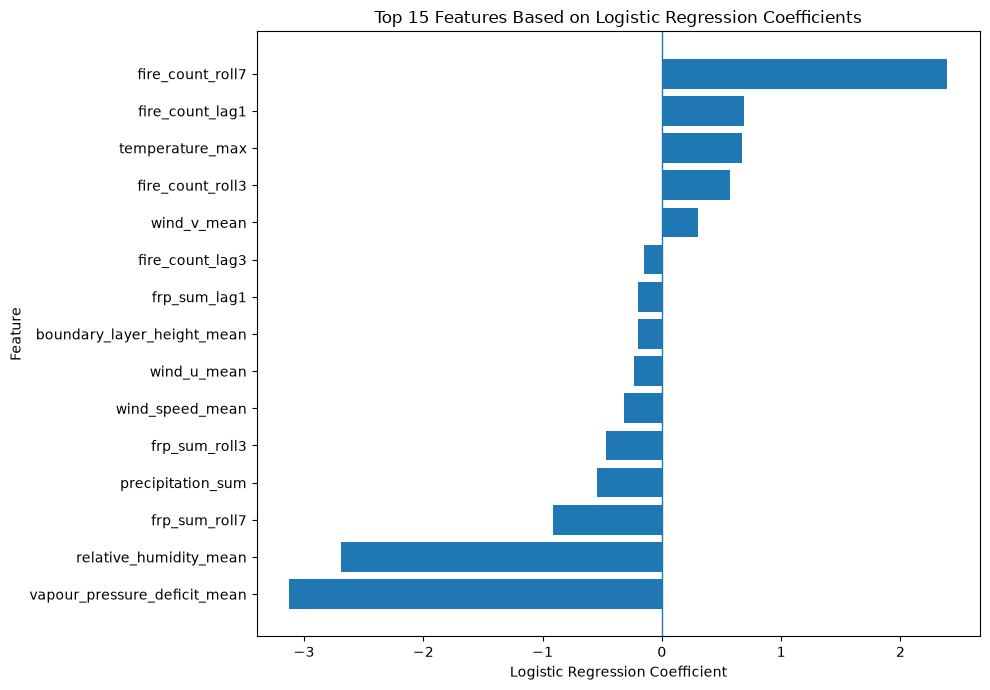

In [56]:
import matplotlib.pyplot as plt

plot_coef_b = (
    coef_b_df
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_coef_b["Feature"],
    plot_coef_b["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features Based on Logistic Regression Coefficients"
)

plt.tight_layout()
plt.show()

In [57]:
from sklearn.inspection import permutation_importance

perm_b = permutation_importance(
    lr_model_b,
    X_val_b,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_b_df = pd.DataFrame({
    "Feature": model_b_cols,
    "Importance_Mean": perm_b.importances_mean,
    "Importance_Std": perm_b.importances_std
})

perm_b_df = perm_b_df.sort_values(
    "Importance_Mean",
    ascending=False
).reset_index(drop=True)

perm_b_df.head(15)

,Feature,Importance_Mean,Importance_Std
0,fire_count_roll7,0.507170,0.006293
1,fire_count_lag1,0.148149,0.004513
2,fire_count_roll3,0.139620,0.004943
3,vapour_pressure_deficit_mean,0.081412,0.001163
4,relative_humidity_mean,0.061208,0.001329
5,frp_sum_roll7,0.035672,0.002627
6,fire_count_lag7,0.032157,0.001721
7,temperature_max,0.025928,0.000973
8,frp_sum_roll3,0.021197,0.002530
9,frp_sum_lag1,0.009647,0.001732


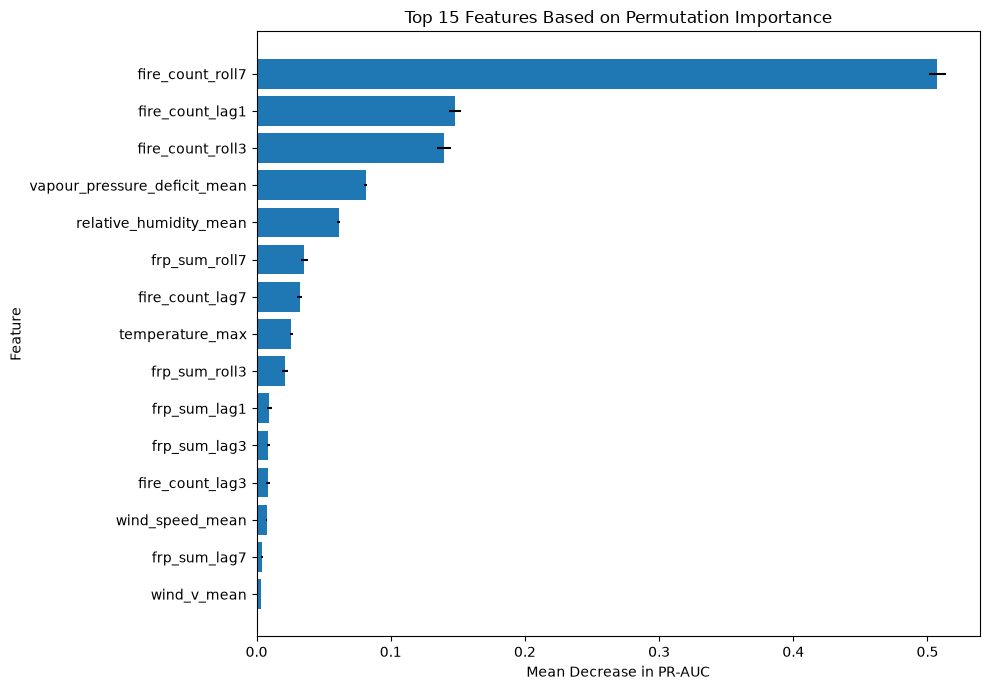

In [58]:
plot_perm_b = (
    perm_b_df
    .head(15)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_perm_b["Feature"],
    plot_perm_b["Importance_Mean"],
    xerr=plot_perm_b["Importance_Std"]
)

plt.xlabel("Mean Decrease in PR-AUC")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features Based on Permutation Importance"
)

plt.tight_layout()
plt.show()

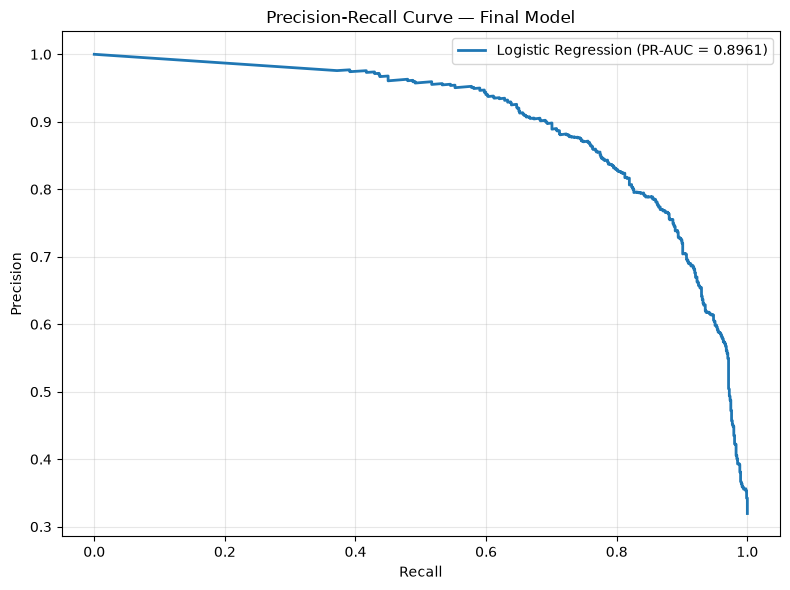

In [59]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_prob_b
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Logistic Regression (PR-AUC = {test_pr_auc_b:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final Model")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

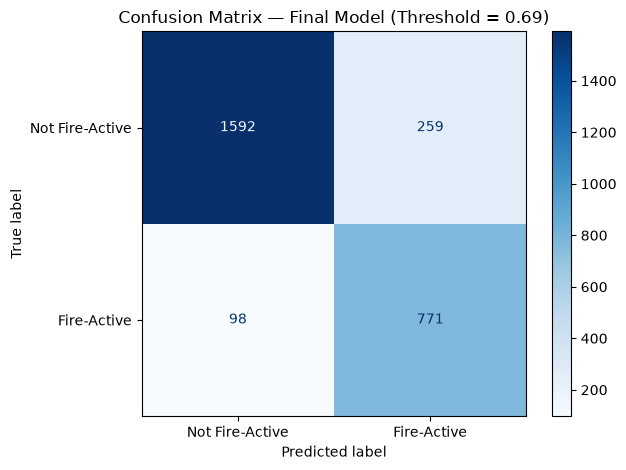

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_b,
    display_labels=["Not Fire-Active", "Fire-Active"],
    cmap="Blues",
    values_format="d"
)

plt.title(
    f"Confusion Matrix — Final Model (Threshold = {FINAL_THRESHOLD_B:.2f})"
)

plt.tight_layout()
plt.show()